In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SWEEP = Path("../data/selection_sweep")   # run from repo root
GRIDS = {
    "tier3":   SWEEP / "tier3_grid",
    "exit":    SWEEP / "exit_grid",
    "confirm": SWEEP / "backtrader_confirm",
}
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [13]:
def load_arm(grid: str, arm: str) -> dict:
    """Load one arm's artifacts. equity has a DatetimeIndex; trades/rejections as-is."""
    d = GRIDS[grid] / arm
    eq = pd.read_parquet(d / "equity.parquet")
    if "date" in eq.columns:
        eq["date"] = pd.to_datetime(eq["date"])
        eq = eq.set_index("date")
    out = {"equity": eq, "metrics": json.loads((d / "metrics.json").read_text()),
           "config": json.loads((d / "config.json").read_text())}
    tp = d / "trades.parquet"
    if tp.exists():
        t = pd.read_parquet(tp)
        for c in ("entry_date", "exit_date"):
            t[c] = pd.to_datetime(t[c])
        out["trades"] = t
    rp = d / "rejections.parquet"
    if rp.exists():
        out["rejections"] = pd.read_parquet(rp)
    return out

def grid_arms(grid: str) -> list[str]:
    return sorted(p.name for p in GRIDS[grid].iterdir() if p.is_dir())

def load_comparison(grid: str) -> pd.DataFrame:
    """The ranked summary.json rows as a DataFrame."""
    s = json.loads((GRIDS[grid] / "summary.json").read_text())
    return pd.DataFrame(s["runs"]).sort_values("sharpe_ratio", ascending=False)

print("tier3 arms:", grid_arms("tier3"))
load_comparison("tier3")

tier3 arms: ['T3_sl10_tpATR2', 'T3_sl10_tpDflt', 'T3_sl10_tpTight', 'T3_sl15_tpATR2', 'T3_sl15_tpDflt', 'T3_sl15_tpTight']


,id,description,signal,model,sharpe_ratio,total_return_pct,max_drawdown_pct,win_rate_pct,total_trades,sqn,n_rejections
5,T3_sl15_tpTight,Tier3 interaction: stop 15% × TP tpTight,binary,m01_binary/v1,1.103316,860.629407,45.204011,44.276458,463,2.423129,952479
2,T3_sl10_tpDflt,Tier3 interaction: stop 10% × TP tpDflt,binary,m01_binary/v1,0.871061,417.749472,50.840442,37.417219,604,1.318185,952324
1,T3_sl10_tpATR2,Tier3 interaction: stop 10% × TP tpATR2,binary,m01_binary/v1,0.786628,317.070532,55.682002,42.257598,691,1.557040,952249
0,T3_sl10_tpTight,Tier3 interaction: stop 10% × TP tpTight,binary,m01_binary/v1,0.762652,303.146115,51.433810,36.842105,608,1.213399,952320
3,T3_sl15_tpDflt,Tier3 interaction: stop 15% × TP tpDflt,binary,m01_binary/v1,0.753051,300.081387,54.221947,42.398287,467,1.203779,952471
4,T3_sl15_tpATR2,Tier3 interaction: stop 15% × TP tpATR2,binary,m01_binary/v1,0.437504,81.994205,63.258401,46.181818,550,0.757116,952395


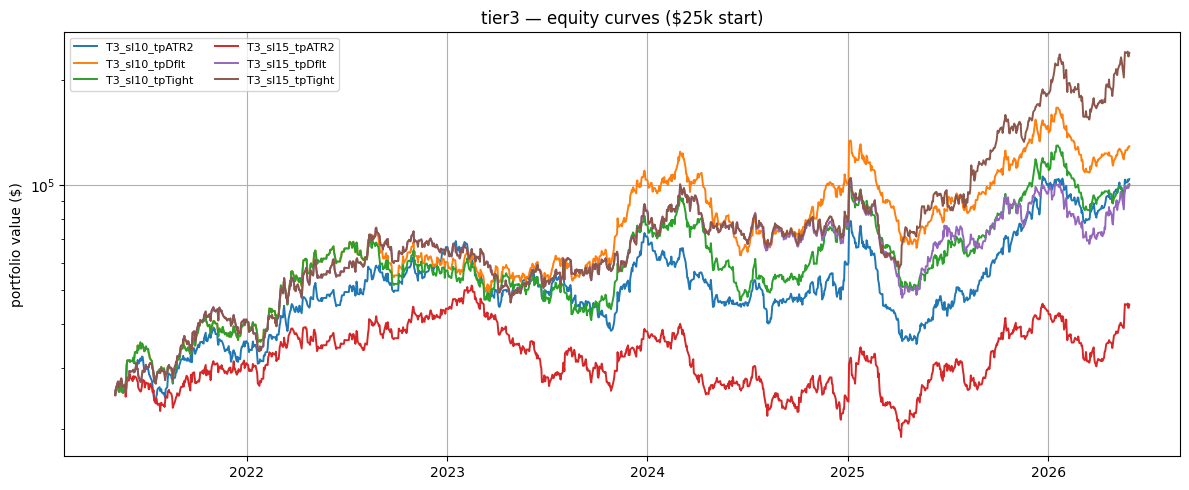

In [14]:
def plot_equity(grid: str, arms: list[str] | None = None, logy: bool = True):
    arms = arms or grid_arms(grid)
    fig, ax = plt.subplots()
    for arm in arms:
        eq = load_arm(grid, arm)["equity"]
        ax.plot(eq.index, eq["value"], label=arm, lw=1.4)
    ax.set_title(f"{grid} — equity curves ($25k start)")
    ax.set_ylabel("portfolio value ($)")
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

plot_equity("tier3")

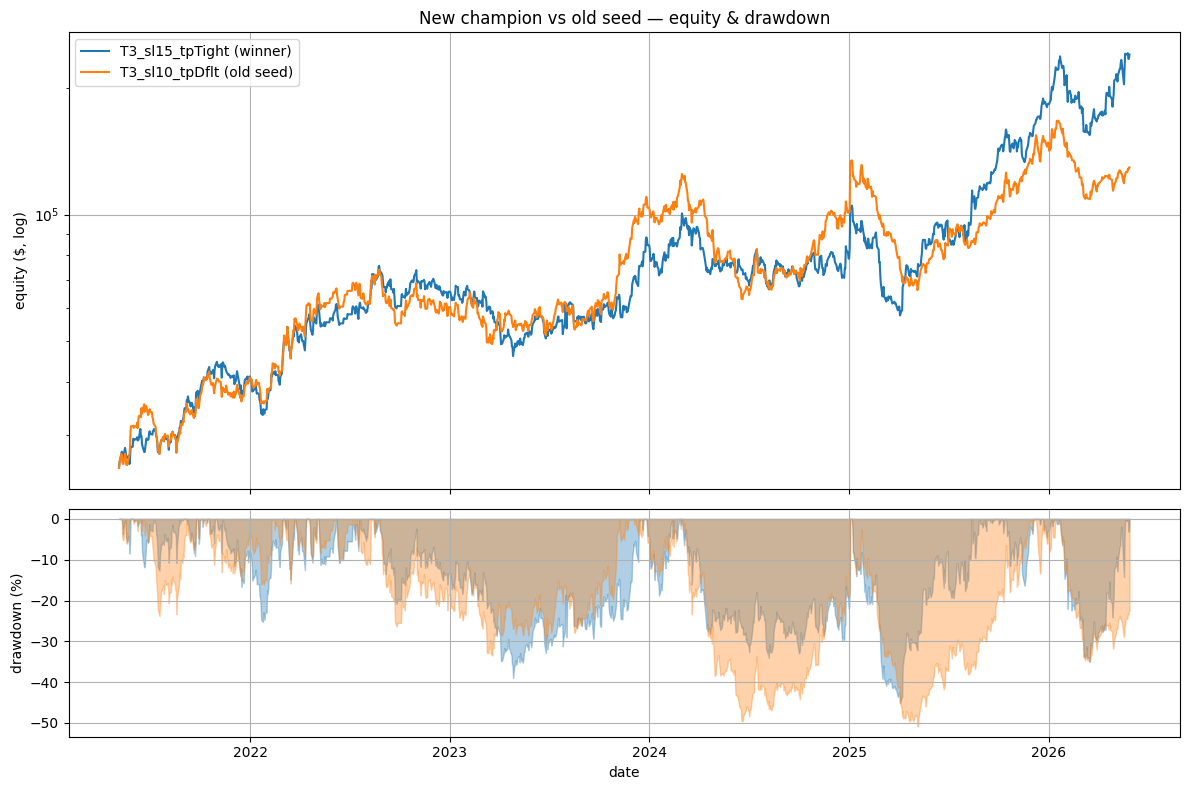

,T3_sl15_tpTight,T3_sl10_tpDflt
sharpe_ratio,1.103316,0.871061
total_return,860.629407,417.749472
max_drawdown,45.204011,50.840442
win_rate,44.276458,37.417219
total_trades,463.000000,604.000000
sqn,2.423129,1.318185


In [15]:
def drawdown(eq: pd.Series) -> pd.Series:
    return eq / eq.cummax() - 1.0

WINNER, OLD = "T3_sl15_tpTight", "T3_sl10_tpDflt"   # new champion vs prior seed
w, o = load_arm("tier3", WINNER), load_arm("tier3", OLD)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8),
                               gridspec_kw={"height_ratios": [2, 1]})
for lbl, d, c in [(f"{WINNER} (winner)", w, "C0"), (f"{OLD} (old seed)", o, "C1")]:
    eq = d["equity"]["value"]
    ax1.plot(eq.index, eq, label=lbl, color=c, lw=1.5)
    ax2.fill_between(eq.index, drawdown(eq) * 100, 0, color=c, alpha=0.35)
ax1.set_yscale("log"); ax1.set_ylabel("equity ($, log)"); ax1.legend()
ax1.set_title("New champion vs old seed — equity & drawdown")
ax2.set_ylabel("drawdown (%)"); ax2.set_xlabel("date")
plt.tight_layout(); plt.show()

# headline metrics side by side
pd.DataFrame({WINNER: w["metrics"], OLD: o["metrics"]}).loc[
    ["sharpe_ratio", "total_return", "max_drawdown", "win_rate", "total_trades", "sqn"]
]

                    count      mean  pct_of_trades
exit_reason                                       
stop                  383  4.530602           83.3
trend                  49 -5.049096           10.7
regime_liquidation     28  0.748550            6.1


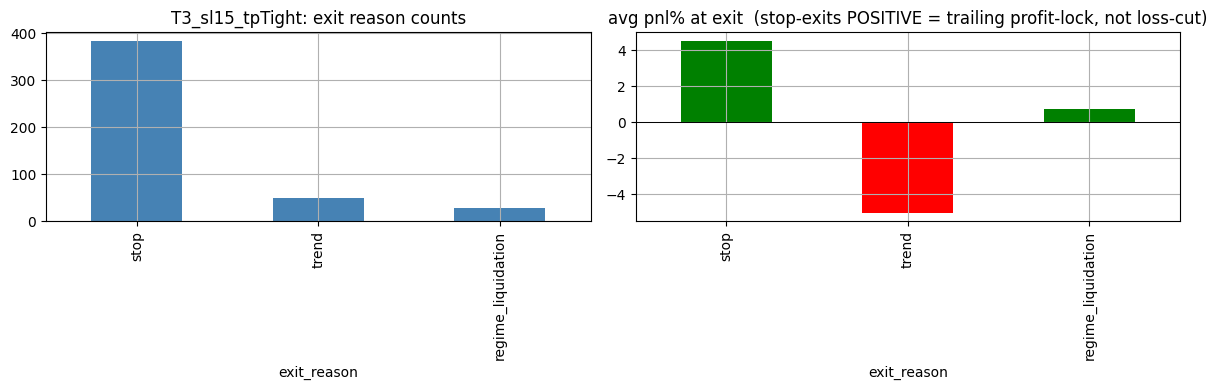

In [16]:
def exit_breakdown(grid: str, arm: str):
    t = load_arm(grid, arm)["trades"]
    g = t.groupby("exit_reason")["pnl_percent"].agg(["count", "mean"]).sort_values("count", ascending=False)
    g["pct_of_trades"] = (g["count"] / len(t) * 100).round(1)
    return g

WINNER = "T3_sl15_tpTight"
bd = exit_breakdown("tier3", WINNER)
print(bd)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
bd["count"].plot.bar(ax=a1, color="steelblue"); a1.set_title(f"{WINNER}: exit reason counts")
bd["mean"].plot.bar(ax=a2, color=["g" if v > 0 else "r" for v in bd["mean"]])
a2.set_title("avg pnl% at exit  (stop-exits POSITIVE = trailing profit-lock, not loss-cut)")
a2.axhline(0, color="k", lw=0.7)
plt.tight_layout(); plt.show()

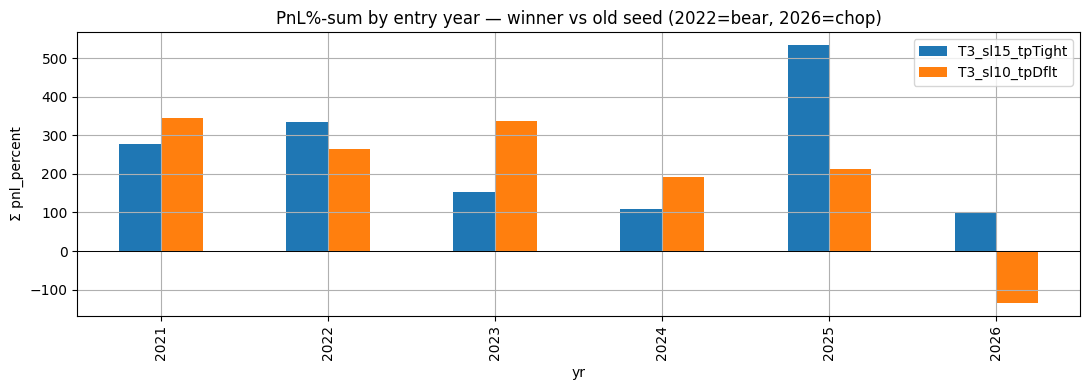

,T3_sl15_tpTight,T3_sl10_tpDflt
yr,,
2021,276.0,346.0
2022,335.0,264.0
2023,154.0,339.0
2024,108.0,191.0
2025,534.0,213.0
2026,101.0,-134.0


In [17]:
def yearly_pnl(grid: str, arms: list[str]) -> pd.DataFrame:
    rows = {}
    for arm in arms:
        t = load_arm(grid, arm)["trades"]
        rows[arm] = t.assign(yr=t["entry_date"].dt.year).groupby("yr")["pnl_percent"].sum()
    return pd.DataFrame(rows)

yp = yearly_pnl("tier3", ["T3_sl15_tpTight", "T3_sl10_tpDflt"])
ax = yp.plot.bar(figsize=(11, 4))
ax.set_title("PnL%-sum by entry year — winner vs old seed (2022=bear, 2026=chop)")
ax.axhline(0, color="k", lw=0.7); ax.set_ylabel("Σ pnl_percent")
plt.tight_layout(); plt.show()
yp.round(0)

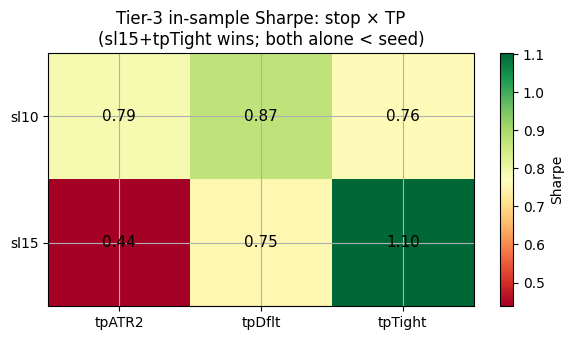

In [18]:
comp = load_comparison("tier3").set_index("id")
# arm id = T3_<sl>_<tp>  →  pivot stop × TP
def parse(a):
    _, sl, tp = a.split("_")
    return sl, tp
rows = [(*parse(a), comp.loc[a, "sharpe_ratio"]) for a in comp.index]
piv = pd.DataFrame(rows, columns=["stop", "tp", "sharpe"]).pivot(index="stop", columns="tp", values="sharpe")

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(piv.columns)), piv.columns)
ax.set_yticks(range(len(piv.index)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i, j]:.2f}", ha="center", va="center", fontsize=11)
ax.set_title("Tier-3 in-sample Sharpe: stop × TP\n(sl15+tpTight wins; both alone < seed)")
fig.colorbar(im, ax=ax, label="Sharpe")
plt.tight_layout(); plt.show()

                 agg_OOS_sharpe  agg_OOS_ret  agg_OOS_maxDD  fold0_sharpe  \
arm                                                                         
T3_sl15_tpTight            1.47         2.45          -0.28          1.86   
T3_sl10_tpDflt             1.28         1.72          -0.36          1.96   

                 fold1_sharpe  fold2_sharpe  
arm                                          
T3_sl15_tpTight          0.12          2.45  
T3_sl10_tpDflt          -0.54          2.36  


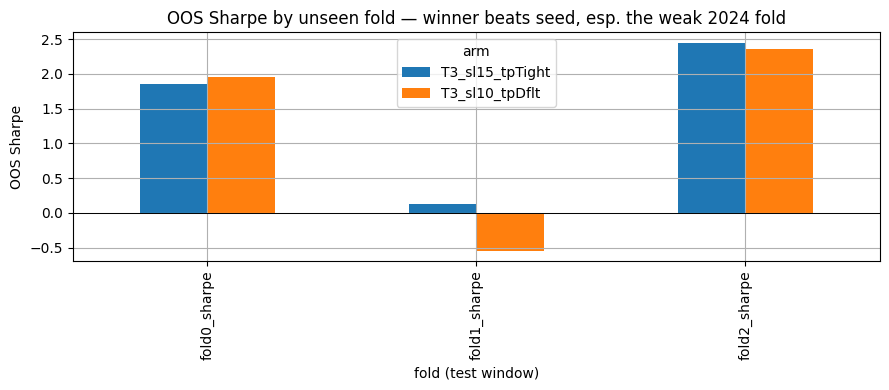

In [19]:
def load_gate(arm: str) -> dict:
    return json.loads((SWEEP / "wfo_gate" / f"{arm}.json").read_text())

def gate_table(arms: list[str]) -> pd.DataFrame:
    out = []
    for a in arms:
        g = load_gate(a)
        row = {"arm": a, "agg_OOS_sharpe": g["aggregate_oos"]["sharpe"],
               "agg_OOS_ret": g["aggregate_oos"].get("total_return"),
               "agg_OOS_maxDD": g["aggregate_oos"]["max_drawdown"]}
        for i, f in enumerate(g["folds"]):
            row[f"fold{i}_sharpe"] = f["sharpe"]
        out.append(row)
    return pd.DataFrame(out).set_index("arm")

gate = gate_table(["T3_sl15_tpTight", "T3_sl10_tpDflt"])
print(gate.round(2))

# per-fold OOS Sharpe bars — winner vs old seed
fold_cols = [c for c in gate.columns if c.startswith("fold")]
ax = gate[fold_cols].T.plot.bar(figsize=(9, 4))
ax.set_title("OOS Sharpe by unseen fold — winner beats seed, esp. the weak 2024 fold")
ax.axhline(0, color="k", lw=0.7); ax.set_ylabel("OOS Sharpe"); ax.set_xlabel("fold (test window)")
plt.tight_layout(); plt.show()

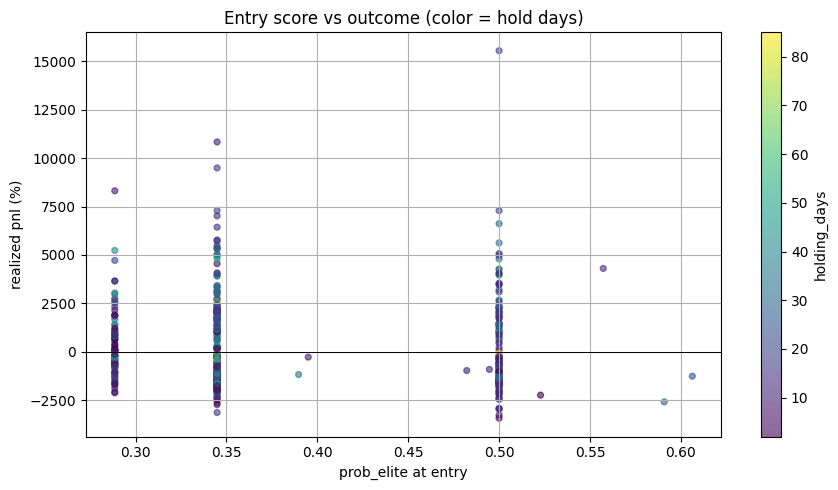

                count   mean
prob_bin                    
(0.288, 0.345]    318  3.760
(0.345, 0.5]      138  2.395
(0.5, 0.606]        4 -4.385


In [20]:
t = load_arm("tier3", "T3_sl15_tpTight")["trades"]
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(t["prob_elite"], t["pnl_percent"] * 100, c=t["holding_days"],
                cmap="viridis", alpha=0.6, s=18)
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("prob_elite at entry"); ax.set_ylabel("realized pnl (%)")
ax.set_title("Entry score vs outcome (color = hold days)")
fig.colorbar(sc, label="holding_days")
plt.tight_layout(); plt.show()

# does higher entry score => higher avg pnl? (score-as-sorter check)
t["prob_bin"] = pd.qcut(t["prob_elite"], 5, duplicates="drop")
print(t.groupby("prob_bin", observed=True)["pnl_percent"].agg(["count", "mean"]).round(3))

In [21]:
def show_trades(grid: str, arm: str, ticker: str | None = None, n: int = 10) -> pd.DataFrame:
    t = load_arm(grid, arm)["trades"]
    if ticker:
        t = t[t["ticker"] == ticker]
    cols = ["ticker", "entry_date", "entry_price", "exit_date", "exit_price",
            "exit_reason", "entry_regime", "prob_elite", "pnl_percent", "holding_days", "mae_pct"]
    return t.sort_values("pnl_percent", ascending=False)[cols].head(n)

# biggest winners of the champion
show_trades("tier3", "T3_sl15_tpTight", n=10)

,ticker,entry_date,entry_price,exit_date,exit_price,exit_reason,entry_regime,prob_elite,pnl_percent,holding_days,mae_pct
328,CRNC,2024-12-19,7.41741,2025-01-07,18.941039,stop,3,0.500000,155.359209,19,-2.256985
390,NEGG,2025-08-04,56.05600,2025-08-15,116.763117,stop,3,0.344828,108.297269,11,-7.235622
249,ALT,2023-12-12,5.95595,2023-12-29,11.608380,stop,3,0.344828,94.903924,17,-20.919414
218,AAOI,2023-08-02,7.63763,2023-08-11,13.986000,stop,3,0.288530,83.119633,9,-14.895066
420,AXTI,2025-12-18,14.07406,2026-01-08,24.345630,stop,4,0.344828,72.982281,21,-9.407804
38,AEHR,2021-09-07,9.18918,2021-09-27,15.884100,stop,4,0.500000,72.856545,20,-10.764622
424,HYMC,2026-01-08,26.71669,2026-01-21,45.464490,stop,4,0.344828,70.172615,13,-6.313245
417,OLMA,2025-11-18,19.82981,2025-12-18,32.947020,stop,3,0.500000,66.148944,30,-8.672852
172,CPS,2022-12-29,8.66866,2023-01-13,14.245740,stop,1,0.344828,64.336131,15,-12.558572
376,AEVA,2025-06-02,17.55754,2025-06-20,27.692280,stop,2,0.344828,57.723007,18,-5.453725


total rejections: 952479
reason
no_slots           783562
no_data            162147
already_holding      5699
cooldown              858
low_price             213
Name: count, dtype: int64


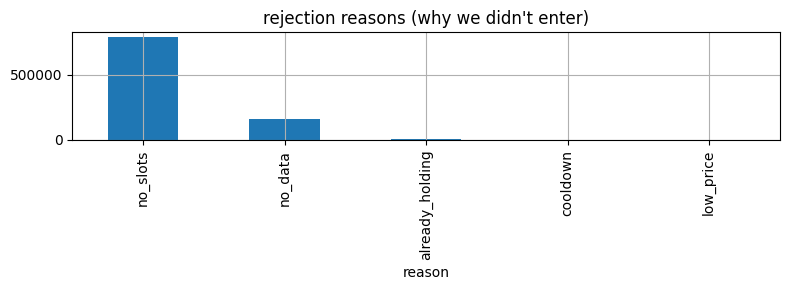

In [22]:
r = load_arm("tier3", "T3_sl15_tpTight")["rejections"]
print("total rejections:", len(r))
print(r["reason"].value_counts())
# no_slots dominating => the book is capacity-bound, not signal-bound (working as designed)
r["reason"].value_counts().plot.bar(figsize=(8, 3), title="rejection reasons (why we didn't enter)")
plt.tight_layout(); plt.show()